In [1]:
import os
import json
import numpy as np
from matplotlib import pyplot as plt

/gpfs-flash/junlab/liyuan/hongwei/DGIL/logs/dot/officehome/0/13/DGIL_con_1_dom_1_dot_no_reset_slca_no_fake_1993_vit_base_patch16_224_dot.log
/gpfs-flash/junlab/liyuan/hongwei/DGIL/logs/dot/officehome/0/13/DGIL_con_1_dom_1_slca_1993_vit_base_patch16_224_dot.log
/gpfs-flash/junlab/liyuan/hongwei/DGIL/logs/dot/officehome/0/13/DGIL_con_1_dom_1_dot_no_reset_slca_1993_vit_base_patch16_224_dot.log
/gpfs-flash/junlab/liyuan/hongwei/DGIL/logs/dot/officehome/0/13/DGIL_con_1_dom_1_slca_no_fake_1993_vit_base_patch16_224_dot.log


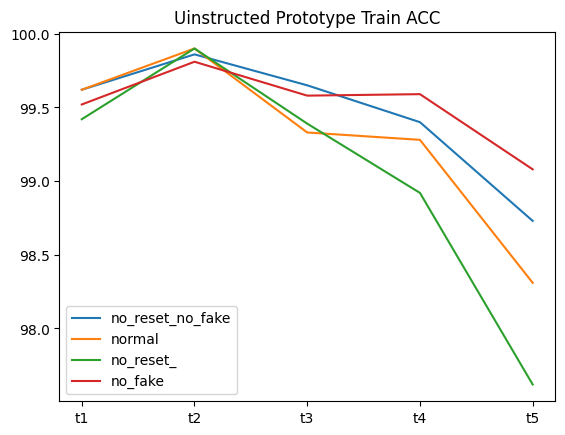

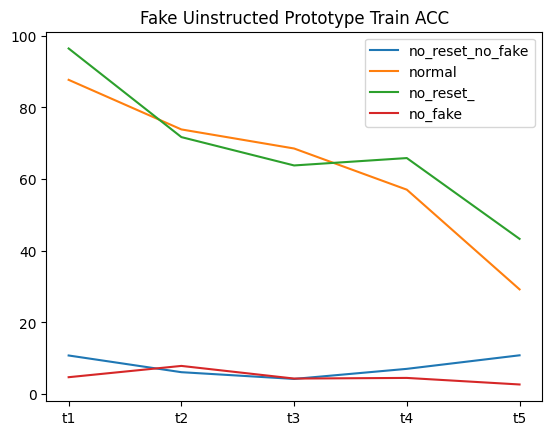

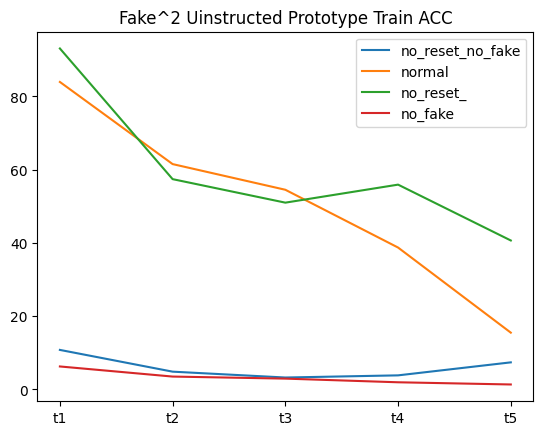

In [ ]:
root_folder  =  "/gpfs-flash/junlab/liyuan/hongwei/DGIL/logs/dot/officehome/0/13"

train_acc_list = {}
train_acc_fake_list = {}
train_acc_fake_2_list = {}

for root, dirs, files in os.walk(root_folder):
    for file in files:
        if file.endswith(".log"):
            label = ""
            if "no_reset" in file:
                label += "no_reset_"
            if "no_fake" in file:
                label += "no_fake"
            if label == "":
                label = "normal"
            train_acc_list[label] = []
            train_acc_fake_list[label] = []
            train_acc_fake_2_list[label] = []
            log_file = os.path.join(root, file)
            print(log_file)
            with open(log_file, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    if "[dot.py] => Head Task" in line:
                        # example: 2025-01-27 05:59:46,443 [dot.py] => Head Task 3, Epoch 5/5 => Loss 0.037, Train_accy 98.92, Train_accy_fake 65.86, Train_accy_fake_2 55.90, Test_accy 77.61
                        train_acc = float(line.split("Train_accy ")[1].split(",")[0])
                        train_acc_list[label].append(train_acc)
                        train_acc_fake = float(line.split("Train_accy_fake ")[1].split(",")[0])
                        train_acc_fake_list[label].append(train_acc_fake)
                        train_acc_fake_2 = float(line.split("Train_accy_fake_2 ")[1].split(",")[0])
                        train_acc_fake_2_list[label].append(train_acc_fake_2)

for file in train_acc_list:
    plt.plot(train_acc_list[file], label=file)

plt.xticks(range(len(train_acc_list["normal"])), ["t1", "t2", "t3", "t4", "t5"])
plt.title("Uinstructed Prototype Train ACC")
plt.legend()
plt.show()


for file in train_acc_fake_list:
    plt.plot(train_acc_fake_list[file], label=file)

plt.xticks(range(len(train_acc_fake_list["normal"])), ["t1", "t2", "t3", "t4", "t5"])
plt.title("Fake Uinstructed Prototype Train ACC")
plt.legend()
plt.show()


for file in train_acc_fake_2_list:
    plt.plot(train_acc_fake_2_list[file], label=file)

plt.xticks(range(len(train_acc_fake_2_list["normal"])), ["t1", "t2", "t3", "t4", "t5"])
plt.title("Fake^2 Uinstructed Prototype Train ACC")
plt.legend()
plt.show()